# SHAP API

A guided exploration of SHAP (SHapley Additive exPlanations):
- **Explainer**: wraps a trained ML model and computes Shapley values
- **Explanation**: holds SHAP values, baseline prediction, and feature data
- **Plots**: visualize feature contributions locally (per prediction) and globally

## Imports and Setup

In [1]:
%load_ext autoreload
%autoreload 2

import logging
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

import sklearn.datasets
import sklearn.linear_model

warnings.filterwarnings("ignore")

In [2]:
import helpers.hdbg as hdbg
import helpers.hnotebook as hnotebook

hdbg.init_logger(verbosity=logging.INFO)
_LOG = logging.getLogger(__name__)
hnotebook.config_notebook()

try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore

INFO  > cmd='/opt/venv/lib/python3.12/site-packages/ipykernel_launcher.py -f /root/.local/share/jupyter/runtime/kernel-e30c7a25-5152-4b1f-96fc-83f236f291da.json'


## Library Overview

- **What problem it solves**:
  - Modern ML models (tree ensembles, neural nets) are accurate but opaque
  - SHAP answers "why did the model predict X?" for any single prediction
  - Decomposes predictions into per-feature contributions grounded in game
    theory (Shapley values from cooperative game theory)

- **Key abstraction**:
  - Every prediction = baseline + sum of per-feature SHAP values
  - Shapley values satisfy consistency, dummy, and efficiency axioms (no other
    attribution satisfying all three exists)

- **Mental model**:
// TODO(ai_gp): Make this into a markdown table (object, description, comments)
  ```
  model: X -> prediction
  Explainer(model, background) -> configured explainer
  explainer(X) -> Explanation
  Explanation.values       shape (n_samples, n_features): per-feature SHAP
  Explanation.base_values  shape (n_samples,): E[model(X)] baseline
  Explanation.data         shape (n_samples, n_features): original feature values
  prediction[i] = base_values[i] + values[i].sum()
  ```

- **Key classes**:
  - `shap.LinearExplainer`: exact for linear models (used throughout this notebook)
  - `shap.TreeExplainer`: fast and exact for tree-based models
  - `shap.KernelExplainer`: model-agnostic, works with any callable
  - `shap.Explanation`: result object (values, base_values, data)

# Part 1: Toy Data Setup

## Cell 1.1: Create a toy regression dataset

**Goal**:
- Build the minimal dataset needed to explore all SHAP primitives
- Use regression (not classification) to keep SHAP values 2D and easy to inspect

In [3]:
# Four named features, 30 samples, pure regression target.
np.random.seed(42)
X, y = sklearn.datasets.make_regression(
    n_samples=30,
    n_features=4,
    n_informative=3,
    noise=10.0,
    random_state=42,
)
X_df = pd.DataFrame(X, columns=["age", "income", "debt", "employment"])
y_s = pd.Series(y, name="target")

print("X_df.shape=", X_df.shape)
print("y_s.shape=", y_s.shape)
display(X_df.head(3))

X_df.shape= (30, 4)
y_s.shape= (30,)


,age,income,debt,employment
0,-1.150994,0.375698,0.110923,-0.544383
1,1.477894,-0.518270,0.357113,-0.219672
2,-1.106335,-1.196207,-0.185659,-0.479174


In [26]:
# TODO(ai_gp): Split this into 3 cells.
# Data analysis: correlations and basic statistics
print("=== Feature Statistics ===")
print(X_df.describe())

print("\n=== Correlations with target ===")
corr_with_target = X_df.corrwith(y_s).sort_values(ascending=False)
display(corr_with_target)

print("\n=== Feature Correlations ===")
# TODO(ai_gp): Make this a heatmap
display(X_df.corr())

=== Feature Statistics ===
             age     income       debt  employment
count  30.000000  30.000000  30.000000   30.000000
mean   -0.087220   0.052238  -0.118841   -0.162853
std     1.057838   1.015968   0.953432    0.652970
min    -2.619745  -1.987569  -1.959670   -1.478522
25%    -0.567134  -0.551283  -0.481479   -0.586575
50%    -0.033448   0.185720  -0.205718   -0.098556
75%     0.576115   0.903936   0.346396    0.253653
max     1.886186   1.852278   2.463242    1.465649

=== Correlations with target ===


debt          0.849101
age           0.450942
employment    0.216763
income        0.162737
dtype: float64


=== Feature Correlations ===


,age,income,debt,employment
age,1.000000,0.119687,-0.025191,0.013751
income,0.119687,1.000000,0.154812,-0.064533
debt,-0.025191,0.154812,1.000000,0.007042
employment,0.013751,-0.064533,0.007042,1.000000


## Cell 1.2: Train a linear regression model

**Goal**:
- Train a `LinearRegression` model on the toy dataset
- This is the single model we will explain end-to-end throughout the notebook

In [27]:
# Train linear regression model.
linear_model = sklearn.linear_model.LinearRegression()
linear_model.fit(X_df, y_s)
print("linear_model=", linear_model)

linear_model= LinearRegression()


In [28]:
# Show linear model coefficients and intercept.
coef_df = pd.DataFrame({
    "feature": X_df.columns,
    "coefficient": linear_model.coef_,
})
coef_df["abs_coef"] = np.abs(coef_df["coefficient"])
display(coef_df.sort_values("abs_coef", ascending=False))
print(f"Intercept: {linear_model.intercept_:.6f}")

,feature,coefficient,abs_coef
2,debt,73.851940,73.851940
0,age,36.423134,36.423134
3,employment,25.442104,25.442104
1,income,-1.124521,1.124521


Intercept: 3.158971


# Part 2: Primitive 1 - The Explainer

## Cell 2.1: Construct a LinearExplainer

**Mental model**:
- `LinearExplainer` wraps a linear model together with background data
- Background data captures feature means and covariances used to compute
  conditional expectations
- For a linear model $f(x) = w \cdot x + b$, the SHAP value for feature $j$ is
  exactly $w_j \cdot (x_j - E[x_j])$

In [ ]:
# TODO(ai_gp): Explain better background data, what it is, what it is useful for?

In [29]:
# Construct LinearExplainer with model and background data.
linear_explainer = shap.LinearExplainer(linear_model, X_df)
print("type(linear_explainer)=", type(linear_explainer))
print("linear_explainer.expected_value=", linear_explainer.expected_value)

type(linear_explainer)= <class 'shap.explainers._linear.LinearExplainer'>
linear_explainer.expected_value= -12.996543788805079


## Cell 2.2: Inspect the LinearExplainer

In [30]:
# expected_value is E[model(X)], the global baseline.
print("linear_explainer.expected_value=", linear_explainer.expected_value)
print("mean of y (approx baseline)=", round(y_s.mean(), 4))
# Interpretation: expected_value equals the model's average prediction over the
# training set, which is the intercept offset from the mean-centered features.
print("\nInterpretation: expected_value = model's average output (~mean of y).")
print("SHAP values = deviations from this baseline for each feature.")

linear_explainer.expected_value= -12.996543788805079
mean of y (approx baseline)= -12.9965

Interpretation: expected_value = model's average output (~mean of y).
SHAP values = deviations from this baseline for each feature.


In [31]:
# Public interface of the LinearExplainer.
import inspect

# TODO(ai_gp): Merge this code in print_public_methods renaming use_markdown to mode = "dataframe", "markdown", "raw_output"

methods_list = []
for name in dir(linear_explainer):
    if not name.startswith("_"):
        attr = getattr(linear_explainer, name)
        if callable(attr):
            try:
                sig = inspect.signature(attr)
                doc = inspect.getdoc(attr)
                doc_short = doc.split("\n")[0] if doc else ""
                methods_list.append({
                    "Method": name,
                    "Signature": str(sig),
                    "Description": doc_short,
                })
            except (ValueError, TypeError):
                pass
methods_df = pd.DataFrame(methods_list)
display(methods_df)

,Method,Signature,Description
0,explain_row,"(*row_args: Any, max_evals: Union[int, Literal...",Explains a single row and returns the tuple (r...
1,link,(x: 'npt.NDArray[Any] | float') -> 'npt.NDArra...,A no-op link function.
2,load,"(in_file: 'Any', model_loader: 'Callable[..., ...",Load an Explainer from the given file stream.
3,masker,"(mask, x)",This masks out tabular features by integrating...
4,save,"(out_file: 'Any', model_saver: 'str | Callable...",Write the explainer to the given file stream.
5,shap_values,"(X: numpy.ndarray[tuple[typing.Any, ...], nump...",Estimate the SHAP values for a set of samples.
6,supports_model_with_masker,"(model: Any, masker: Any) -> bool",Determines if we can parse the given model.


# Part 3: Primitive 2 - The Explanation Object

`Explanation` object: The central data structure for SHAP
An `Explanation` bundles three key arrays:
1. `.values`: SHAP contributions
   - shape: n_samples x n_features
   - How much each feature "pushed" the prediction away from baseline
   - Positive = increases prediction, Negative = decreases prediction
3. `.base_values`: Model's average output
   - shape: n_samples, all usually identical
   - The expected value / baseline prediction
   - Same for all samples unless model has per-sample defaults
5. `.data`: Original input features
   - shape: n_samples x n_features
   - Needed for plots that correlate feature value with SHAP impact

Additive property:

```
prediction[i] = base_values[i] + sum(values[i, :])
```

This always holds exactly for tree and linear explainers. 

## Cell 3.1: Compute SHAP values (get an `Explanation`)

**Mental model**:
- Calling `explainer(X)` returns an `Explanation` object
- This bundles SHAP values, baseline, and original data into one structure
- For `LinearExplainer`, SHAP values are exact (no sampling)

In [10]:
# Compute SHAP values for all 30 samples using LinearExplainer.
explanation = linear_explainer(X_df)
print("type(explanation)=", type(explanation))

type(explanation)= <class 'shap._explanation.Explanation'>


## Cell 3.2: Inspect `Explanation.values`

In [11]:
# .values: SHAP contribution of each feature for each sample.
print("type(explanation.values)=", type(explanation.values))
print("explanation.values.shape=", explanation.values.shape)
# Rows = samples, columns = features.
values_df = pd.DataFrame(explanation.values, columns=X_df.columns)
display(values_df.head(3))

type(explanation.values)= <class 'numpy.ndarray'>
explanation.values.shape= (30, 4)


,age,income,debt,employment
0,-38.745962,-0.363738,16.968456,-9.706908
1,57.006364,0.641549,35.150064,-1.445581
2,-37.119356,1.403902,-4.934668,-8.047867


## Cell 3.3: Inspect `Explanation.base_values`

In [12]:
# .base_values: model's expected output (same for all samples).
print("explanation.base_values.shape=", explanation.base_values.shape)
print("explanation.base_values[0]=", round(explanation.base_values[0], 4))
print(
    "all identical?",
    np.allclose(explanation.base_values, explanation.base_values[0]),
)

explanation.base_values.shape= (30,)
explanation.base_values[0]= -12.9965
all identical? True


## Cell 3.4: Inspect `Explanation.data`

In [13]:
# .data: the original feature values passed to the explainer.
print("type(explanation.data)=", type(explanation.data))
print("explanation.data.shape=", explanation.data.shape)
display(pd.DataFrame(explanation.data, columns=X_df.columns).head(3))

type(explanation.data)= <class 'numpy.ndarray'>
explanation.data.shape= (30, 4)


,age,income,debt,employment
0,-1.150994,0.375698,0.110923,-0.544383
1,1.477894,-0.518270,0.357113,-0.219672
2,-1.106335,-1.196207,-0.185659,-0.479174


## Cell 3.5: Verify the additive decomposition

**Key invariant**:
- `prediction[i] = base_value + sum(shap_values[i])`
- This always holds exactly for TreeExplainer (and LinearExplainer)

In [14]:
# Verify additive decomposition for sample index 0.
idx = 0
model_pred = linear_model.predict(X_df.iloc[[idx]])[0]
shap_sum = explanation.base_values[idx] + explanation.values[idx].sum()
print("model_pred=", round(model_pred, 6))
print("base + sum(shap)=", round(shap_sum, 6))
print("match?", np.isclose(model_pred, shap_sum))

model_pred= -44.844696
base + sum(shap)= -44.844696
match? True


# Part 4: Primitive 3 - SHAP Plots

## Cell 4.1: Waterfall plot (single prediction)

**Goal**:
- See how each feature pushes prediction above or below the baseline for one sample
- Start at `E[f(X)]` (bottom), end at `f(x)` (model output)

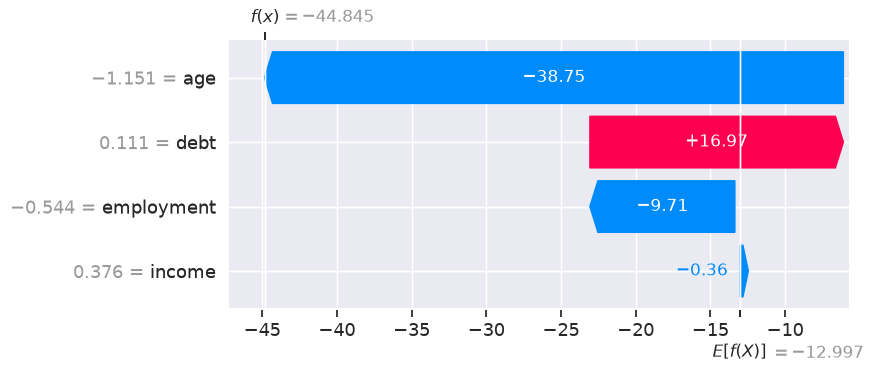

In [18]:
# Waterfall plot for sample 0: shows individual feature contributions.
shap.plots.waterfall(explanation[0])
plt.close("all")

**Key observations**:
- Each horizontal bar = one feature's SHAP contribution
- Red: feature pushes prediction up
- Blue: feature pushes prediction down
- Total = base_value + signed sum of all bars = model output

## Cell 4.2: Bar plot (global feature importance)

**Goal**:
- Rank features by their average absolute SHAP value across all samples
- This is the global view: which features matter most overall?

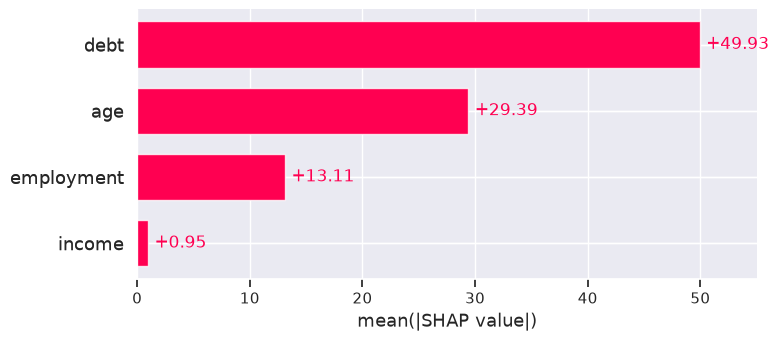

In [19]:
# Bar plot: mean |SHAP value| per feature across all samples.
shap.plots.bar(explanation)
plt.close("all")

**Key observations**:
- Bar length = mean(|SHAP value|) averaged across 30 samples
- Longer bar = feature matters more globally
- Does not show direction (sign), only magnitude

## Cell 4.3: Beeswarm plot (global distribution of SHAP values)

**Goal**:
- Show the distribution of SHAP values per feature across all samples
- Color encodes the feature value (red = high, blue = low)

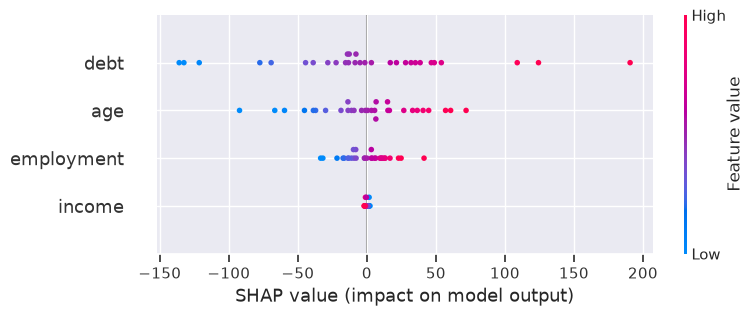

In [20]:
# Beeswarm: one dot per (sample, feature), color = feature value.
shap.plots.beeswarm(explanation)
plt.close("all")

**Key observations**:
- Each dot = one sample's SHAP value for a given feature
- Horizontal spread = range of SHAP contributions for that feature
- Red dots with high SHAP -> high feature value increases the prediction
- Blue dots with low SHAP -> low feature value decreases the prediction

## Cell 4.4: Scatter plot (feature dependence)

**Goal**:
- See how a single feature's value relates to its SHAP contribution
- Reveals linear, monotonic, or threshold-based effects

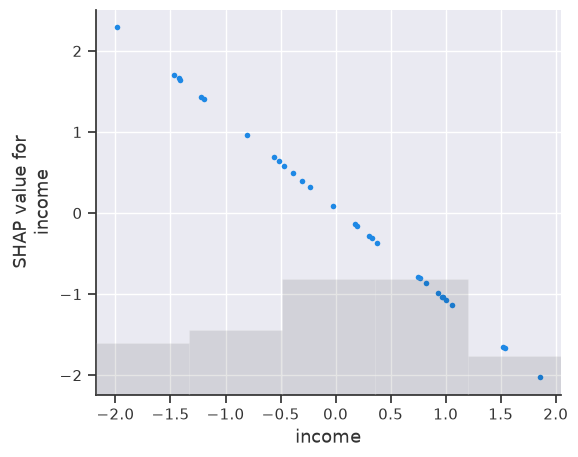

In [21]:
# Scatter: x = feature value, y = SHAP contribution for "income".
shap.plots.scatter(explanation[:, "income"])
plt.close("all")

**Key observations**:
- x-axis: raw feature value (income)
- y-axis: SHAP contribution for income
- A diagonal line -> monotonic effect; an S-curve -> threshold or saturation

# Part 5: API Patterns

## Cell 5.1: Local explanation for a specific sample

Build a per-sample breakdown table of feature values and their SHAP contributions.

In [22]:
# Table: feature value, SHAP value, and absolute SHAP for sample 5.
sample_idx = 5
local_df = pd.DataFrame(
    {
        "feature_value": X_df.iloc[sample_idx].values,
        "shap_value": explanation.values[sample_idx],
        "abs_shap": np.abs(explanation.values[sample_idx]),
    },
    index=X_df.columns,
).sort_values("abs_shap", ascending=False)
display(local_df)

,feature_value,shap_value,abs_shap
debt,-0.719844,-44.385284,44.385284
employment,-1.478522,-33.473376,33.473376
age,-0.460639,-13.601077,13.601077
income,1.057122,-1.130014,1.130014


## Cell 5.2: Global importance as a sorted DataFrame

Rank features by mean absolute SHAP value across all samples.

In [23]:
# Global feature ranking by mean absolute SHAP.
global_importance_df = pd.DataFrame(
    {
        "feature": X_df.columns,
        "mean_abs_shap": np.abs(explanation.values).mean(axis=0),
        "mean_shap": explanation.values.mean(axis=0),
    }
).sort_values("mean_abs_shap", ascending=False)
display(global_importance_df)

,feature,mean_abs_shap,mean_shap
2,debt,49.928186,1.184238e-15
0,age,29.392221,-1.539509e-15
3,employment,13.112381,-3.256654e-16
1,income,0.954521,7.401487e-18


## Cell 5.3: Sign of SHAP values

- Positive SHAP: feature increases prediction above baseline
- Negative SHAP: feature decreases prediction below baseline

In [24]:
# Count positive vs negative SHAP values per feature across all samples.
sign_df = pd.DataFrame(
    {
        "n_positive": (explanation.values > 0).sum(axis=0),
        "n_negative": (explanation.values < 0).sum(axis=0),
    },
    index=X_df.columns,
)
display(sign_df)

,n_positive,n_negative
age,16,14
income,14,16
debt,13,17
employment,16,14


# Part 6: Other Explainer Types

This notebook used `LinearExplainer` end-to-end because it gives exact, interpretable
SHAP values for linear models. SHAP also provides two other key explainer types:

- **`shap.TreeExplainer`**: for tree-based models (decision trees, random forests, gradient
  boosting)
  - Traverses the tree structure to compute exact Shapley values in polynomial time
  - No background data required: the tree encodes the full conditional distribution
  - Usage: `expl = shap.TreeExplainer(tree_model)`

- **`shap.KernelExplainer`**: model-agnostic, works with any callable
  - Approximates Shapley values by sampling perturbations of the input
  - Slower than `TreeExplainer` but works with any model (sklearn, TensorFlow, etc.)
  - Requires a small background dataset (often summarized with `shap.kmeans`)
  - Usage: `expl = shap.KernelExplainer(model.predict, shap.kmeans(X_df, k=5))`

All three explainers share the same interface: call with data, get back an `Explanation`
object with `.values`, `.base_values`, and `.data`. The additive decomposition
`prediction[i] = base_values[i] + values[i].sum()` holds for all of them.

# Part 7: Summary

## Summary: The Mental Model

- **`LinearExplainer` (main focus)**: exact SHAP values for linear models; SHAP
  value for feature $j$ is $w_j \cdot (x_j - E[x_j])$; requires the trained model
  and background data
- **`Explanation` object**: the central data structure with three arrays:
  `.values` (SHAP contributions, shape `(n_samples, n_features)`),
  `.base_values` (model's average prediction), and `.data` (input feature values)
- **Additive decomposition**: `prediction[i] = base_values[i] + values[i].sum()`
  holds exactly for `LinearExplainer` — SHAP values are a faithful partition of
  each prediction
- **Plots**: `waterfall` for single-prediction breakdown, `bar` for global
  magnitude ranking, `beeswarm` for global distribution with direction, and
  `scatter` for feature-level dependence analysis
- **Other explainers**: `TreeExplainer` for tree-based models (exact, fast),
  `KernelExplainer` for any callable (approximate, model-agnostic) — all share
  the same `Explanation` interface